# Extractor efficiency comparison

This chart gives the expected number of physical coin tosses or die rolls required to obtain one valid highest-slot extraction. It compares every face-count extractor used in the experiments and each available bias profile.

For an $n$-face source, an attempt consumes $n$ launches. The chance that the attempt is valid is the chance that its highest face occurs exactly once, so expected launches per valid result is $n / P(\text{valid})$.

Extractor            Bias             Valid blocks   Launches / valid result
Coin (2 faces)       Fair                  50.00%                     4.00
Coin (2 faces)       Minimal bias          49.82%                     4.01
Coin (2 faces)       High bias             32.00%                     6.25
Die (6 faces)        Fair                  56.91%                    10.54
Die (6 faces)        Minimal bias          52.41%                    11.45
Die (6 faces)        High bias              9.69%                    61.94
Die (8 faces)        Fair                  57.23%                    13.98
Die (8 faces)        Minimal bias          50.73%                    15.77
Die (8 faces)        High bias              9.84%                    81.33
Die (16 faces)       Fair                  57.72%                    27.72
Die (16 faces)       Minimal bias          43.22%                    37.02
Die (16 faces)       High bias              5.90%                   271.14


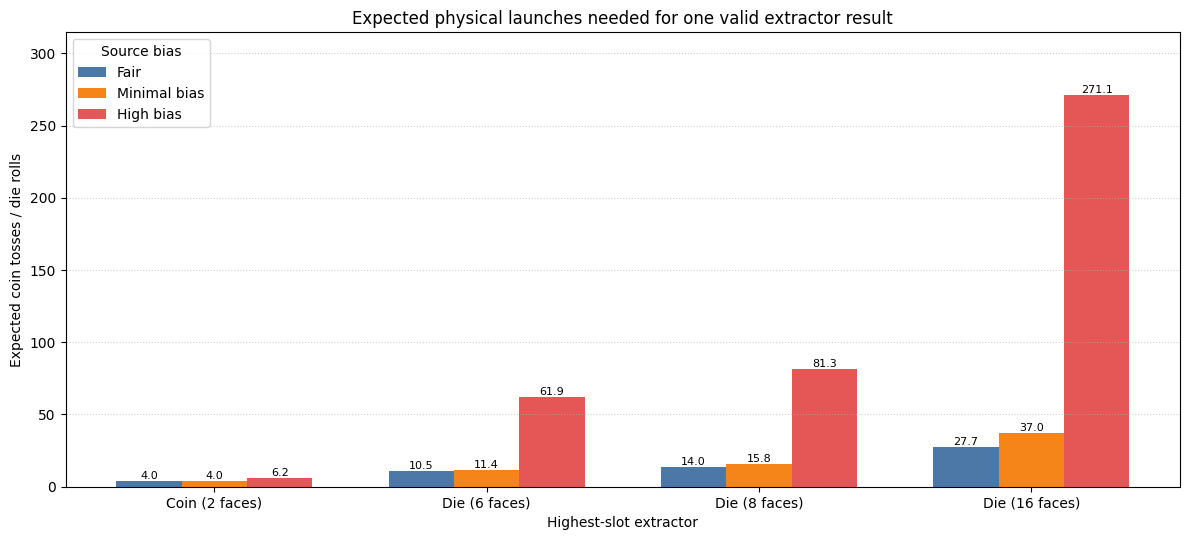

In [1]:
import matplotlib.pyplot as plt
import numpy as np

EXTRACTORS = {
    'Coin (2 faces)': {
        'Fair': [0.50, 0.50],
        'Minimal bias': [0.47, 0.53],
        'High bias': [0.20, 0.80],
    },
    'Die (6 faces)': {
        'Fair': [1 / 6] * 6,
        'Minimal bias': [0.16, 0.16, 0.16, 0.16, 0.16, 0.20],
        'High bias': [0.05, 0.05, 0.10, 0.10, 0.20, 0.50],
    },
    'Die (8 faces)': {
        'Fair': [1 / 8] * 8,
        'Minimal bias': [0.12] * 7 + [0.16],
        'High bias': [0.6 / 7] * 7 + [0.40],
    },
    'Die (16 faces)': {
        'Fair': [1 / 16] * 16,
        'Minimal bias': [0.06] * 15 + [0.10],
        'High bias': [0.75 / 15] * 15 + [0.25],
    },
}

def valid_block_probability(weights):
    """Probability that the maximum in one n-launch block is unique."""
    weights = np.asarray(weights, dtype=float)
    lower_probability = np.concatenate(([0.0], np.cumsum(weights[:-1])))
    return np.sum(len(weights) * weights * lower_probability ** (len(weights) - 1))

biases = ['Fair', 'Minimal bias', 'High bias']
rows = []
for extractor, profiles in EXTRACTORS.items():
    for bias in biases:
        weights = profiles[bias]
        acceptance = valid_block_probability(weights)
        rows.append((extractor, bias, acceptance, len(weights) / acceptance))

print(f"{'Extractor':<20} {'Bias':<14} {'Valid blocks':>14} {'Launches / valid result':>25}")
for extractor, bias, acceptance, launches in rows:
    print(f"{extractor:<20} {bias:<14} {acceptance:>13.2%} {launches:>24.2f}")

positions = np.arange(len(EXTRACTORS))
width = 0.24
colors = ['#4c78a8', '#f58518', '#e45756']
fig, axis = plt.subplots(figsize=(12, 5.5))
for offset, bias, color in zip([-width, 0, width], biases, colors):
    values = [next(launches for label, row_bias, _, launches in rows if label == extractor and row_bias == bias) for extractor in EXTRACTORS]
    bars = axis.bar(positions + offset, values, width, label=bias, color=color)
    for bar in bars:
        axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

axis.set(
    title='Expected physical launches needed for one valid extractor result',
    xlabel='Highest-slot extractor',
    ylabel='Expected coin tosses / die rolls',
    xticks=positions,
    xticklabels=list(EXTRACTORS),
    ylim=(0, max(row[3] for row in rows) * 1.16),
)
axis.grid(axis='y', linestyle=':', alpha=0.6)
axis.legend(title='Source bias')
plt.tight_layout()
plt.show()